In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import ScalarFormatter
from matplotlib import font_manager
from pathlib import Path
import os
from os import listdir
from os.path import isfile, join
import pandas as pd
import seaborn as sns
import image_functions as imf

In [2]:
import os

# 1. Dynamically find your conda environment's font path
conda_fonts_path = "/home/cajkag/miniconda3/envs/cellpose/fonts"

# 2. Add any .ttf files found in that directory to the font manager
if os.path.exists(conda_fonts_path):
    font_files = font_manager.findSystemFonts(fontpaths=[conda_fonts_path])
    for font_file in font_files:
        font_manager.fontManager.addfont(font_file)
    print(f"Added {len(font_files)} fonts from {conda_fonts_path}")
else:
    print("Conda font path not found. Check if mscorefonts installed correctly.")

Added 30 fonts from /home/cajkag/miniconda3/envs/cellpose/fonts


In [3]:
# Set global plot parameters
# For better visualization
#%matplotlib inline
#plt.rcParams['figure.figsize'] = (15, 10)

# To ensure text is editbale after saving
plt.rcParams['svg.fonttype'] = "none"

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.family'] = ['Arial']
#mpl.rcParams['font.sans-serif'] = ['DejaVu Sans']
#mpl.rcParams['font.sans-serif'] = ['Lucida Grande']
#mpl.rcParams['font.sans-serif'] = ['Verdana']
#mpl.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Lucida Grande', 'Verdana']
# To remove top and right spines from all plots
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

In [4]:
# Load filtered dataset
df = pd.read_csv("cells_phenotyped_cytosub_mean_filtered_final.csv")
print(df.shape)

(2187, 128)


In [5]:
# Calculate ratios
CHANNEL_NAME = "dCas9-KRAB"

# MeanFI ratio
df[f"min_norm_nuc_to_cyto_{CHANNEL_NAME}_mean_intensity"] = df[f"min_norm_nucleus_{CHANNEL_NAME}_mean_intensity"]/df[f"min_norm_cytoplasm_{CHANNEL_NAME}_mean_intensity"]
print(df[f"min_norm_nuc_to_cyto_{CHANNEL_NAME}_mean_intensity"].min(), df[f"min_norm_nuc_to_cyto_{CHANNEL_NAME}_mean_intensity"].max())

#df[f"min_norm_nuc_to_cyto_{CHANNEL_NAME}_median_intensity"] = df[f"min_norm_nucleus_{CHANNEL_NAME}_median_intensity"]/df[f"min_norm_cytoplasm_{CHANNEL_NAME}_median_intensity"]
#print(df[f"min_norm_nuc_to_cyto_{CHANNEL_NAME}_median_intensity"].min(), df[f"min_norm_nuc_to_cyto_{CHANNEL_NAME}_median_intensity"].max())

#df[f"parental_min_norm_nucleus_{CHANNEL_NAME}_mean_intensity"] = (df[f"min_norm_nucleus_{CHANNEL_NAME}_mean_intensity"] - df[df["experimental_group"] == "Parental"][f"min_norm_nucleus_{CHANNEL_NAME}_mean_intensity"].mean()).clip(lower=1)
#df[f"parental_min_norm_cytoplasm_{CHANNEL_NAME}_mean_intensity"] = (df[f"min_norm_cytoplasm_{CHANNEL_NAME}_mean_intensity"] - df[df["experimental_group"] == "Parental"][f"min_norm_cytoplasm_{CHANNEL_NAME}_mean_intensity"].mean()).clip(lower=1)
#df[f"parental_min_norm_nuc_to_cyto_{CHANNEL_NAME}_mean_intensity"] = df[f"parental_min_norm_nucleus_{CHANNEL_NAME}_mean_intensity"]/df[f"parental_min_norm_cytoplasm_{CHANNEL_NAME}_mean_intensity"]
#print(df[f"parental_min_norm_nuc_to_cyto_{CHANNEL_NAME}_mean_intensity"].min(), df[f"parental_min_norm_nuc_to_cyto_{CHANNEL_NAME}_mean_intensity"].max())


# Summed fractions
df[f"min_norm_cell_{CHANNEL_NAME}_sum_intensity"] = (df[f"min_norm_nucleus_{CHANNEL_NAME}_sum_intensity"] + df[f"min_norm_cytoplasm_{CHANNEL_NAME}_sum_intensity"])
print(df[f"min_norm_cell_{CHANNEL_NAME}_sum_intensity"].min(), df[f"min_norm_cell_{CHANNEL_NAME}_sum_intensity"].max())
df[f"min_norm_nuc_fraction_{CHANNEL_NAME}_sum_intensity"] = df[f"min_norm_nucleus_{CHANNEL_NAME}_sum_intensity"]/df[f"min_norm_cell_{CHANNEL_NAME}_sum_intensity"]
print(df[f"min_norm_nuc_fraction_{CHANNEL_NAME}_sum_intensity"].min(), df[f"min_norm_nuc_fraction_{CHANNEL_NAME}_sum_intensity"].max())

#df[f"parental_min_norm_nucleus_{CHANNEL_NAME}_sum_intensity"] = (df[f"min_norm_nucleus_{CHANNEL_NAME}_sum_intensity"] - df[df["experimental_group"] == "Parental"][f"min_norm_nucleus_{CHANNEL_NAME}_sum_intensity"].mean()).clip(lower=1)
#df[f"parental_min_norm_cytoplasm_{CHANNEL_NAME}_sum_intensity"] = (df[f"min_norm_cytoplasm_{CHANNEL_NAME}_sum_intensity"] - df[df["experimental_group"] == "Parental"][f"min_norm_cytoplasm_{CHANNEL_NAME}_sum_intensity"].mean()).clip(lower=1)
#df[f"parental_min_norm_cell_{CHANNEL_NAME}_sum_intensity"] = df[f"parental_min_norm_nucleus_{CHANNEL_NAME}_sum_intensity"] + df[f"parental_min_norm_cytoplasm_{CHANNEL_NAME}_sum_intensity"]
#print(df[f"parental_min_norm_cell_{CHANNEL_NAME}_sum_intensity"].min(), df[f"parental_min_norm_cell_{CHANNEL_NAME}_sum_intensity"].max())
#df[f"parental_min_norm_nuc_fraction_{CHANNEL_NAME}_sum_intensity"] = df[f"parental_min_norm_nucleus_{CHANNEL_NAME}_sum_intensity"]/df[f"parental_min_norm_cell_{CHANNEL_NAME}_sum_intensity"]
#print(df[f"parental_min_norm_nuc_fraction_{CHANNEL_NAME}_sum_intensity"].min(), df[f"parental_min_norm_nuc_fraction_{CHANNEL_NAME}_sum_intensity"].max())

0.05403788880637159 27.481973530236083
27445.09847179133 4407113.481332
0.07422090330969928 0.9361612259041179


In [6]:
# Group stats
CHANNEL_NAME = "dCas9-KRAB"

measurements = [f"min_norm_nucleus_{CHANNEL_NAME}_mean_intensity",
                f"min_norm_cytoplasm_{CHANNEL_NAME}_mean_intensity",
                f"min_norm_nuc_to_cyto_{CHANNEL_NAME}_mean_intensity",
                f"min_norm_nucleus_{CHANNEL_NAME}_sum_intensity",
                f"min_norm_cytoplasm_{CHANNEL_NAME}_sum_intensity",
                f"min_norm_cell_{CHANNEL_NAME}_sum_intensity",
                f"min_norm_nuc_fraction_{CHANNEL_NAME}_sum_intensity"]
                
stats = ['mean', 
         'median', 
         'min', 
         'max', 
         'std']

group_stats = df.groupby('experimental_group')\
                        .agg({'experimental_group': 'count', **{col: stats for col in measurements}})

group_stats.reset_index(inplace=True)

print(group_stats.shape)
group_stats.head()

(5, 37)


experimental_group       min_norm_nucleus_dCas9-KRAB_mean_intensity  \
                     count                                       mean   
0         2xMeCP2NLS   361                                 234.373944   
1           2xMycNLS   371                                 128.158797   
2    NpNLS+2xSV40NLS   521                                  80.494296   
3           Parental   503                                  43.303769   
4              noNLS   431                                  83.393017   

                                                   \
       median        min          max         std   
0  220.630073  29.595288  1090.580290  110.752686   
1  118.619197  24.265050   371.458957   59.358336   
2   71.757305   3.891988   308.469296   40.441197   
3   43.861576   1.000000    95.353459   15.023323   
4   77.191244   4.569349   278.321987   38.355586   

  min_norm_cytoplasm_dCas9-KRAB_mean_intensity                        ...  \
                                          mean     median        min  ...   
0                                    49.762437  43.824194   4.863460  ...   
1                                    59.367765  53.245591  12.722888  ...   
2                                    77.416720  69.441397   1.389848  ...   
3                                    36.674984  34.056241   1.000000  ...   
4                                    76.511919  66.293871   5.644119  ...   

  min_norm_cell_dCas9-KRAB_sum_intensity                               \
                                    mean        median            min   
0                           1.109411e+06  1.048721e+06  277773.563395   
1                           7.564722e+05  6.987355e+05  233646.808070   
2                           7.195432e+05  6.664735e+05  100467.327080   
3                           3.582836e+05  3.567039e+05   27445.098472   
4                           6.901673e+05  6.552078e+05  102439.850249   

                               min_norm_nuc_fraction_dCas9-KRAB_sum_intensity  \
            max            std                                           mean   
0  4.407113e+06  444263.220133                                       0.656504   
1  1.776883e+06  317790.006623                                       0.535210   
2  3.240462e+06  329067.682450                                       0.350837   
3  8.049562e+05  120384.636901                                       0.366948   
4  2.673112e+06  299203.343188                                       0.379957   

                                           
     median       min       max       std  
0  0.663295  0.216128  0.936161  0.107882  
1  0.533185  0.096584  0.801978  0.105780  
2  0.331936  0.151469  0.859598  0.106855  
3  0.345693  0.074221  0.852668  0.117660  
4  0.363648  0.082698  0.868373  0.114786  

[5 rows x 37 columns]

In [7]:
group_stats.to_csv('group_stats_mean.csv', index=False)

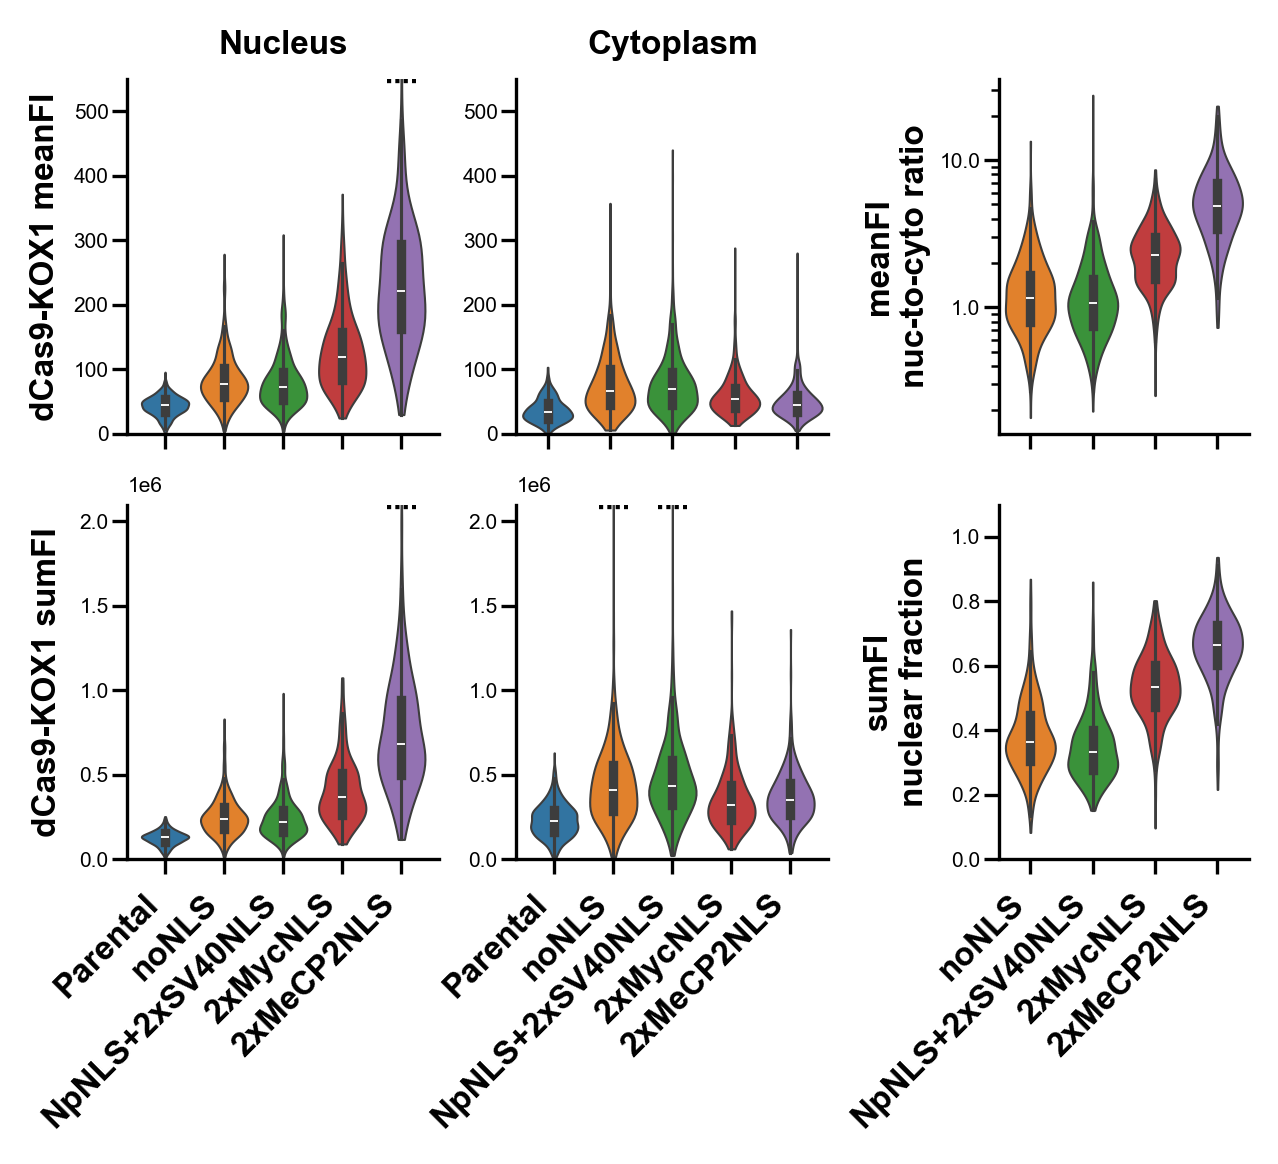

In [43]:
# Plot means and sums
CHANNEL_NAME = "dCas9-KRAB"
COMPARTMENT1 = "nucleus"
COMPARTMENT2 = "cytoplasm"

DF = df
ORDER = ["Parental", "noNLS", "NpNLS+2xSV40NLS", "2xMycNLS", "2xMeCP2NLS"]
LABELS = ["Parental", "noNLS", "NpNLS+2xSV40NLS", "2xMycNLS", "2xMeCP2NLS"]

fig = plt.figure(figsize=(4.2, 4.0), dpi=300)
axes = GridSpec(2, 5, figure=fig, left=0.1, bottom=0.25, right=0.99, top=0.9, width_ratios=[1, 0, 1, 0.3, 0.8])

ax1=fig.add_subplot(axes[0,0])
ax2=fig.add_subplot(axes[0,2])
ax3=fig.add_subplot(axes[0,4])
ax4=fig.add_subplot(axes[1,0])
ax5=fig.add_subplot(axes[1,2])
ax6=fig.add_subplot(axes[1,4])

FONTSIZE = 8
LABELSIZE = 5
LINEWIDTH = 0.5

# Plot 1
sns.violinplot(ax=ax1, data=DF, x="experimental_group", y=f"min_norm_{COMPARTMENT1}_{CHANNEL_NAME}_mean_intensity", order=ORDER, 
               hue="experimental_group",
               hue_order=ORDER,
               inner="boxplot", 
               density_norm="count",
               linewidth = LINEWIDTH,
               cut = 0,
               #log_scale=10
              )
ax1.set_ylim(0, 550)
#ax1.set_xlim(0,)
ax1.set_xlabel("")
ax1.set_ylabel("dCas9-KOX1 meanFI",
               fontsize=FONTSIZE,
               fontweight="bold",
               labelpad=3 # Default is 4
              )

ax1.set_title("Nucleus",
                    fontsize=FONTSIZE,
                    fontweight="bold"
                   )
ax1.set_xticks(ORDER,
                     ["", "", "", "", ""]
                     #fontsize=FONTSIZE,
                     #fontweight="bold",
                     #rotation=45,
                     #ha="right"
                    )
ax1.tick_params(axis='y', 
                labelsize=LABELSIZE, 
                pad=1
               )

# Plot 2
sns.violinplot(ax=ax2, data=DF, x="experimental_group", y=f"min_norm_{COMPARTMENT2}_{CHANNEL_NAME}_mean_intensity", order=ORDER, 
               hue="experimental_group",
               hue_order=ORDER,
               inner="boxplot", 
               density_norm="count",
               linewidth = LINEWIDTH,
               cut = 0,
               #log_scale=10
              )
ax2.set_ylim(0, 550)
ax2.set_xlabel("")
ax2.set_ylabel("")
ax2.set_title("Cytoplasm",
                    fontsize=FONTSIZE,
                    fontweight="bold"
                   )
ax2.set_xticks(ORDER,
                     ["", "", "", "", ""],
                     #fontsize=FONTSIZE,
                     #fontweight="bold",
                     #rotation=45,
                     #ha="right"
                    )
ax2.tick_params(axis='y', 
                labelsize=LABELSIZE, 
                pad=1
               )

# Plot 3
sns.violinplot(ax=ax3, data=DF[DF["experimental_group"] != "Parental"], x="experimental_group", y=f"min_norm_nuc_to_cyto_{CHANNEL_NAME}_mean_intensity", order=ORDER, 
               hue="experimental_group",
               hue_order=ORDER,
               inner="boxplot", 
               density_norm="count",
               linewidth = LINEWIDTH,
               cut = 0,
               log_scale=10
              )
#ax3.set_ylim(0, 1000)
ax3.set_xlim(0.5,)
ax3.set_xlabel("")
ax3.set_ylabel("meanFI\nnuc-to-cyto ratio",
               fontsize=FONTSIZE,
               fontweight="bold",
               labelpad=2 # Default is 4
              )

#ax3.set_title("Cytoplasm",
                    #fontsize=FONTSIZE,
                    #fontweight="bold"
                   #)
ax3.set_xticks(ORDER[1:],
                     ["", "", "", ""],
                     #fontsize=FONTSIZE,
                     #fontweight="bold",
                     #rotation=45,
                     #ha="right"
                    )
ax3.tick_params(axis='y', 
                labelsize=LABELSIZE, 
                pad=1
               )
ax3.yaxis.set_major_formatter(ScalarFormatter())

# Plot 4
sns.violinplot(ax=ax4, data=DF, x="experimental_group", y=f"min_norm_{COMPARTMENT1}_{CHANNEL_NAME}_sum_intensity", order=ORDER, 
               hue="experimental_group",
               hue_order=ORDER,
               inner="boxplot", 
               density_norm="count",
               linewidth = LINEWIDTH,
               cut = 0,
               #log_scale=10
              )
ax4.set_ylim(0, 2100000)
ax4.set_xlabel("")
ax4.set_ylabel("dCas9-KOX1 sumFI",
               fontsize=FONTSIZE,
               fontweight="bold",
               labelpad = 4 # Default is 4
              )
ax4.set_title("")
ax4.set_xticks(ORDER,
                     LABELS,
                     fontsize=FONTSIZE,
                     fontweight="bold",
                     rotation=45,
                     ha="right"
                    )
ax4.tick_params(axis='y', 
                labelsize=LABELSIZE, 
                pad=1
               )
ax4.yaxis.get_offset_text().set_fontsize(LABELSIZE)

# Plot 5
sns.violinplot(ax=ax5, data=DF, x="experimental_group", y=f"min_norm_{COMPARTMENT2}_{CHANNEL_NAME}_sum_intensity", order=ORDER, 
               hue="experimental_group",
               hue_order=ORDER,
               inner="boxplot", 
               density_norm="count",
               linewidth = LINEWIDTH,
               cut = 0,
               #log_scale=10
              )
ax5.set_ylim(0, 2100000)
ax5.set_xlabel("")
ax5.set_ylabel("")
ax5.set_title("")
ax5.set_xticks(ORDER,
                     LABELS,
                     fontsize=FONTSIZE,
                     fontweight="bold",
                     rotation=45,
                     ha="right"
                    )
ax5.tick_params(axis='y', 
                labelsize=LABELSIZE, 
                pad=1
               )
ax5.yaxis.get_offset_text().set_fontsize(LABELSIZE)

# Plot 6
sns.violinplot(ax=ax6, data=DF, x="experimental_group", y=f"min_norm_nuc_fraction_{CHANNEL_NAME}_sum_intensity", order=ORDER,
               hue="experimental_group",
               hue_order=ORDER,
               inner="boxplot", 
               density_norm="count",
               linewidth = LINEWIDTH,
               cut = 0,
              )
ax6.set_xlim(0.5,)
ax6.set_ylim(0,1.1)
ax6.set_xlabel("")
ax6.set_ylabel("sumFI\nnuclear fraction",
               fontsize=FONTSIZE,
               fontweight="bold",
               labelpad = 5 # Default is 4       
              )
ax6.set_xticks((ORDER[1:]),
                     LABELS[1:],
                     fontsize=FONTSIZE,
                     fontweight="bold",
                     rotation=45,
                     ha="right"
                    )
ax6.tick_params(axis='y', 
                labelsize=LABELSIZE,
                pad=1
               )

ax1.plot([3.75,4.25], [550,550], linestyle=(0,(0.5,0.5)), color="black", linewidth=2)
ax4.plot([3.75,4.25], [2100000,2100000], linestyle=(0,(0.5,0.5)), color="black", linewidth=2)
ax5.plot([1.75,2.25], [2100000,2100000], linestyle=(0,(0.5,0.5)), color="black", linewidth=2)
ax5.plot([0.75,1.25], [2100000,2100000], linestyle=(0,(0.5,0.5)), color="black", linewidth=2)

plt.savefig('meanIP_dCas9KRAB_img_quant_mean_sum_cut.svg',
            transparent = True,
            #bbox_inches='tight', 
            #pad_inches=0
            )

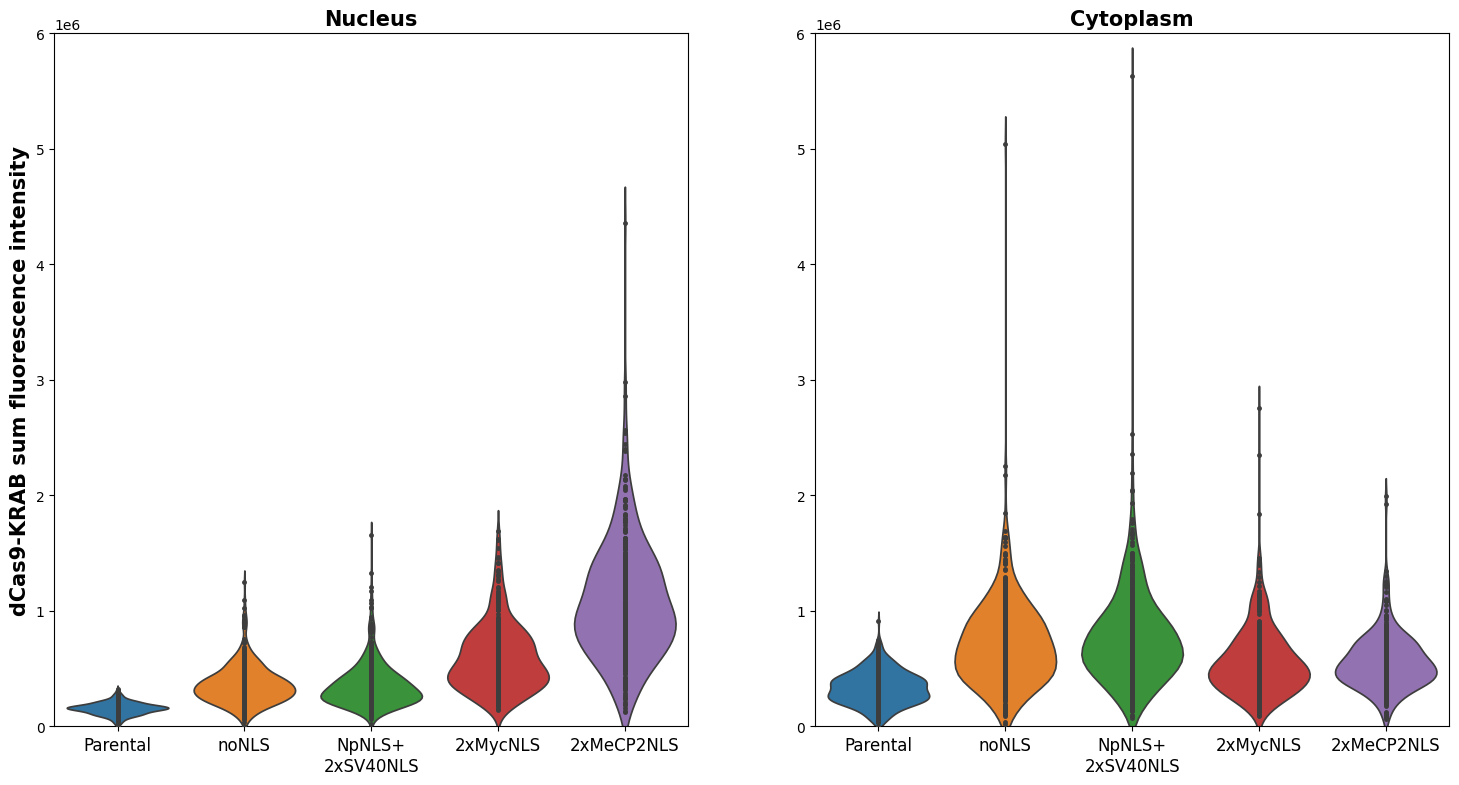

In [58]:
CHANNEL_NAME = "dCas9-KRAB"
COMPARTMENT1 = "nucleus"
COMPARTMENT2 = "cytoplasm"

DF = df
ORDER = ["Parental", "noNLS", "NpNLS+2xSV40NLS", "2xMycNLS", "2xMeCP2NLS"]
fig, axes = plt.subplots(1, 2, figsize=(18,9))

sns.violinplot(ax=axes[0], data=DF, x="experimental_group", y=f"min_norm_{COMPARTMENT1}_{CHANNEL_NAME}_sum_intensity", order=ORDER, 
               hue="experimental_group",
               hue_order=ORDER,
               inner="point", 
               density_norm="count",
               #log_scale=10
              )

sns.violinplot(ax=axes[1], data=DF, x="experimental_group", y=f"min_norm_{COMPARTMENT2}_{CHANNEL_NAME}_sum_intensity", order=ORDER, 
               hue="experimental_group",
               hue_order=ORDER,
               inner="point", 
               density_norm="count",
               #log_scale=10
              )

#axes.set_yscale("log")

axes[0].set_ylim(0, 6000000)
axes[1].set_ylim(0, 6000000)

axes[0].set_xlabel("")
axes[1].set_xlabel("")

axes[0].set_ylabel("dCas9-KRAB sum fluorescence intensity",
                fontsize=15,
                #fontname="Arial",
                fontweight="bold"
                )
axes[1].set_ylabel("")

axes[0].set_title("Nucleus",
                  fontsize=15,
                  fontweight="bold"
                  )
axes[1].set_title("Cytoplasm",
                  fontsize=15,
                  fontweight="bold"
                  )

axes[0].set_xticks(ORDER,
                   ["Parental", "noNLS", "NpNLS+\n2xSV40NLS", "2xMycNLS", "2xMeCP2NLS"])
#axes[0].set_xticklabels(["Parental", "noNLS", "NpNLS+\n2xSV40NLS", "2xMycNLS", "2xMeCP2NLS"],
                       #rotation=45,
                       #ha="right")
axes[1].set_xticks(ORDER,
                   ["Parental", "noNLS", "NpNLS+\n2xSV40NLS", "2xMycNLS", "2xMeCP2NLS"])

axes[0].tick_params(axis='x', labelsize=12, 
                    #labelrotation=45
                   )
axes[1].tick_params(axis='x', labelsize=12)

plt.savefig('dCas9-KRAB_sumFI.svg', bbox_inches='tight', pad_inches=0)

(0.0, 4916046.989597888)

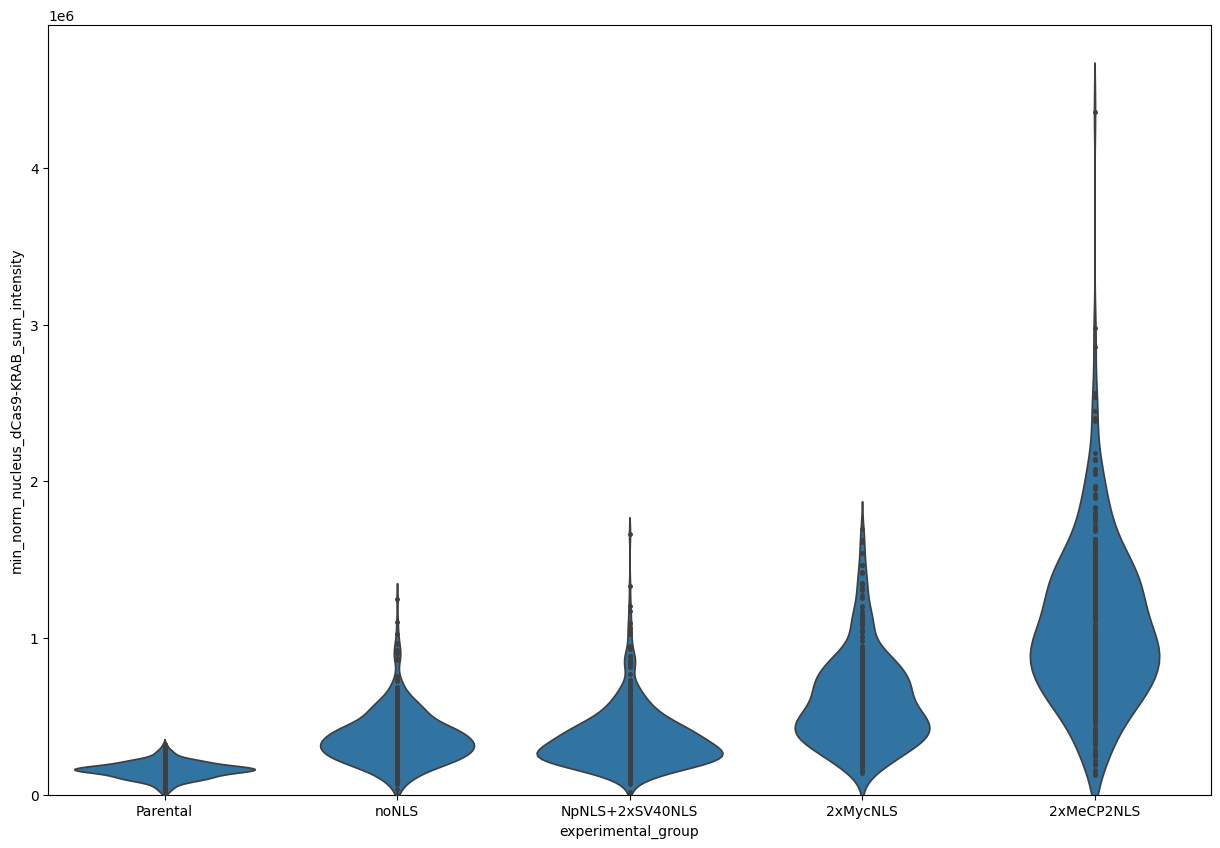

In [13]:
CHANNEL_NAME = "dCas9-KRAB"
COMPARTMENT = "nucleus"

DF = df
ORDER = ["Parental", "noNLS", "NpNLS+2xSV40NLS", "2xMycNLS", "2xMeCP2NLS"]
fig, axes = plt.subplots(figsize=(15,10))

sns.violinplot(ax=axes, data=DF, x="experimental_group", y=f"min_norm_{COMPARTMENT}_{CHANNEL_NAME}_sum_intensity", order=ORDER, 
               inner="point", 
               density_norm="count",
               #log_scale=10
              )

axes.set_ylim(0,)
#axes[].set(title="Tip vs. Total Bill", xlabel="Total Bill ($)", ylabel="Tip ($)")

(0.0, 966.344195231157)

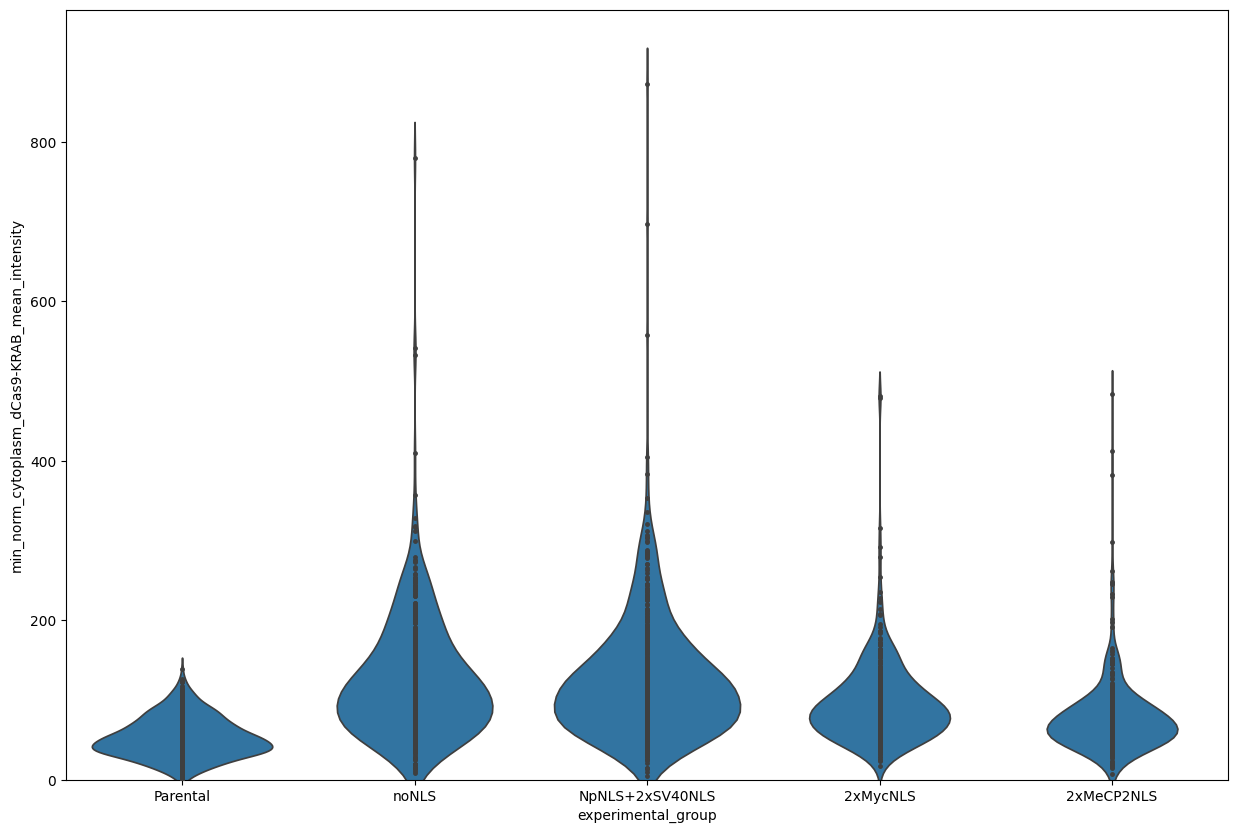

In [21]:
CHANNEL_NAME = "dCas9-KRAB"
COMPARTMENT = "cytoplasm"

DF = df
ORDER = ["Parental", "noNLS", "NpNLS+2xSV40NLS", "2xMycNLS", "2xMeCP2NLS"]
fig, axes = plt.subplots(figsize=(15,10))

sns.violinplot(ax=axes, data=DF, x="experimental_group", y=f"min_norm_{COMPARTMENT}_{CHANNEL_NAME}_mean_intensity", order=ORDER, 
               inner="point", 
               density_norm="count"
              )

axes.set_ylim(0,)
#axes[].set(title="Tip vs. Total Bill", xlabel="Total Bill ($)", ylabel="Tip ($)")

(0.0, 6182327.272246907)

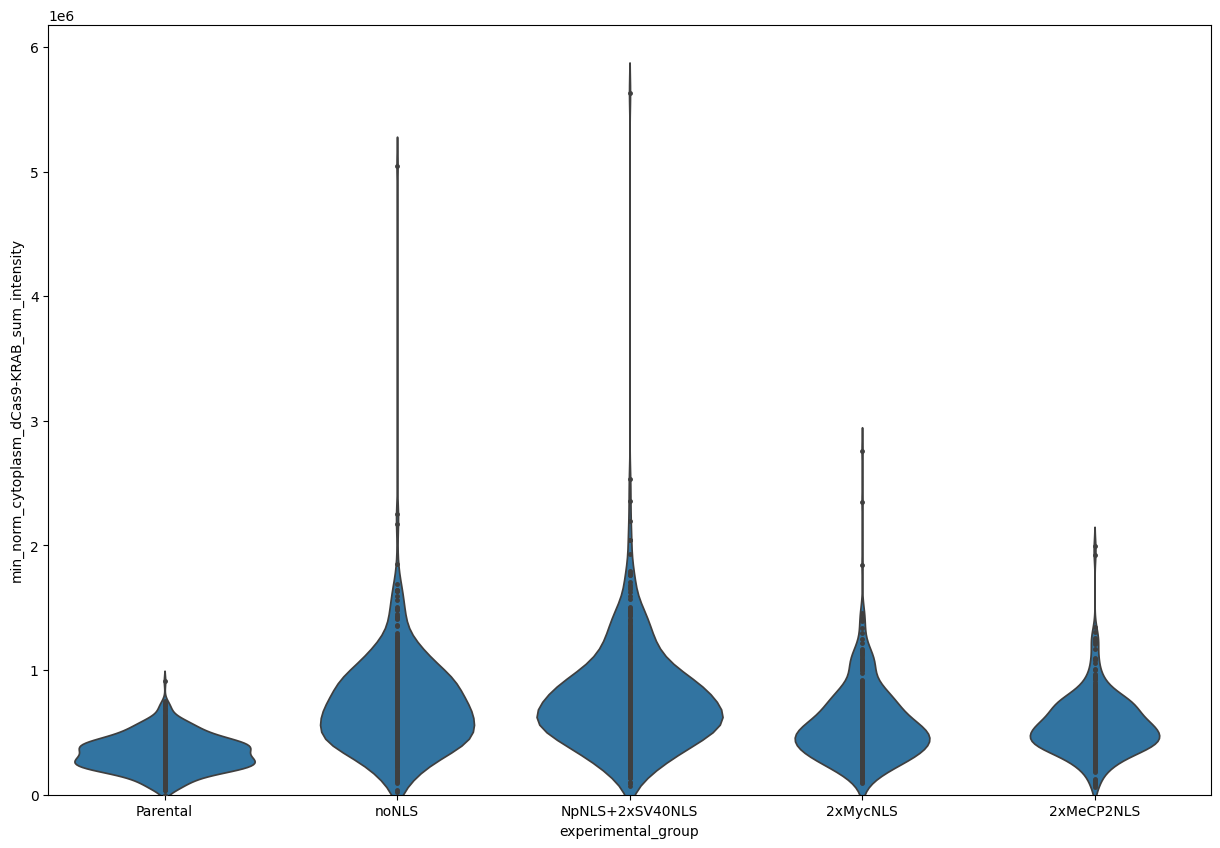

In [14]:
CHANNEL_NAME = "dCas9-KRAB"
COMPARTMENT = "cytoplasm"

DF = df
ORDER = ["Parental", "noNLS", "NpNLS+2xSV40NLS", "2xMycNLS", "2xMeCP2NLS"]
fig, axes = plt.subplots(figsize=(15,10))

sns.violinplot(ax=axes, data=DF, x="experimental_group", y=f"min_norm_{COMPARTMENT}_{CHANNEL_NAME}_sum_intensity", order=ORDER, 
               inner="point", 
               density_norm="count"
              )

axes.set_ylim(0,)
#axes[].set(title="Tip vs. Total Bill", xlabel="Total Bill ($)", ylabel="Tip ($)")

<Axes: xlabel='experimental_group', ylabel='min_norm_nuc_to_cyto_dCas9-KRAB_mean_intensity'>

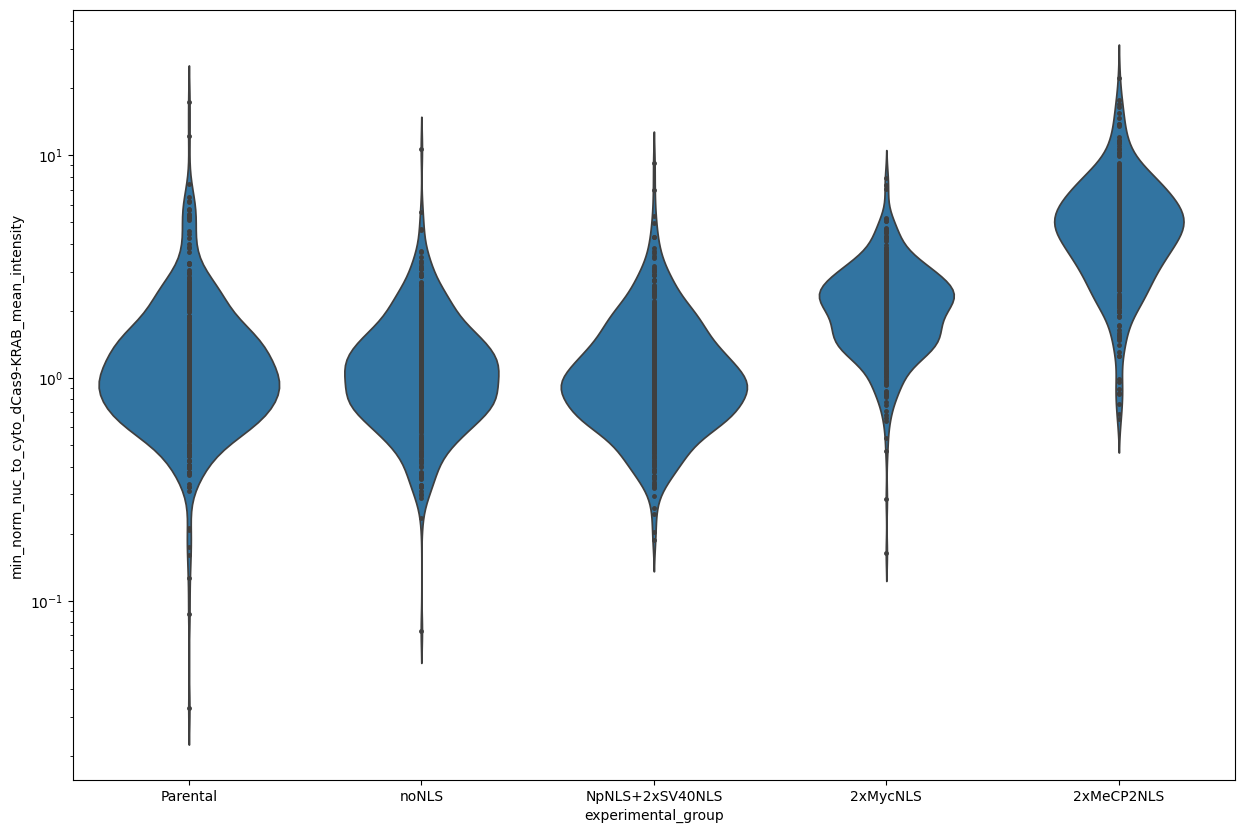

In [16]:
CHANNEL_NAME = "dCas9-KRAB"

DF = df
ORDER = ["Parental", "noNLS", "NpNLS+2xSV40NLS", "2xMycNLS", "2xMeCP2NLS"]
fig, axes = plt.subplots(figsize=(15,10))

sns.violinplot(ax=axes, data=DF, x="experimental_group", y=f"min_norm_nuc_to_cyto_{CHANNEL_NAME}_mean_intensity", order=ORDER, 
               inner="point", 
               density_norm="count",
               log_scale=10
              )

#axes.set_ylim(0,)
#axes[].set(title="Tip vs. Total Bill", xlabel="Total Bill ($)", ylabel="Tip ($)")

(0.0, 1.1260883283149823)

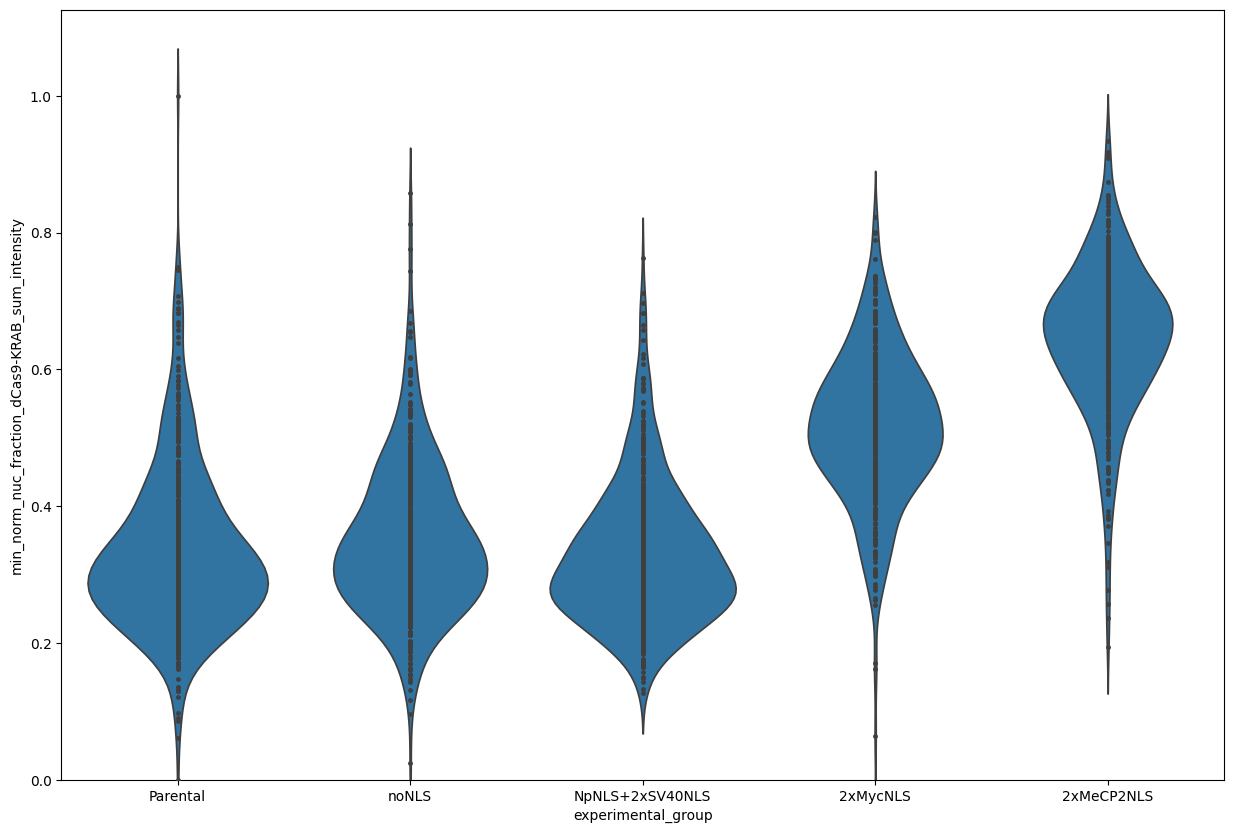

In [17]:
CHANNEL_NAME = "dCas9-KRAB"

DF = df
ORDER = ["Parental", "noNLS", "NpNLS+2xSV40NLS", "2xMycNLS", "2xMeCP2NLS"]
fig, axes = plt.subplots(figsize=(15,10))

sns.violinplot(ax=axes, data=DF, x="experimental_group", y=f"min_norm_nuc_fraction_{CHANNEL_NAME}_sum_intensity", order=ORDER, 
               inner="point", 
               density_norm="count"
              )

axes.set_ylim(0,)
#axes[].set(title="Tip vs. Total Bill", xlabel="Total Bill ($)", ylabel="Tip ($)")

In [23]:
parental = df[df["experimental_group"] == "Parental"].copy()
dCas9 = df[df["experimental_group"] != "Parental"].copy()

In [24]:
parental_nuc_dCas9KRAB_mean = parental["nucleus_dCas9KRAB_mean_intensity"].mean()
parental_nuc_dCas9KRAB_weighted_mean = parental["nucleus_dCas9KRAB_sum_intensity"].sum()/parental["nucleus_area"].sum()
parental_cyto_dCas9KRAB_mean = parental["cytoplasm_dCas9KRAB_mean_intensity"].mean()
parental_cyto_dCas9KRAB_weighted_mean = parental["cytoplasm_dCas9KRAB_sum_intensity"].sum()/parental["cytoplasm_area"].sum()

print(parental_nuc_dCas9KRAB_mean)
print(parental_nuc_dCas9KRAB_weighted_mean)
print(parental_cyto_dCas9KRAB_mean)
print(parental_cyto_dCas9KRAB_weighted_mean)

281.8293999783937
281.134917641062
254.59240496068514
244.5167402561736


<Axes: xlabel='experimental_group', ylabel='norm_nucleus_dCas9KRAB_sum_intensity'>

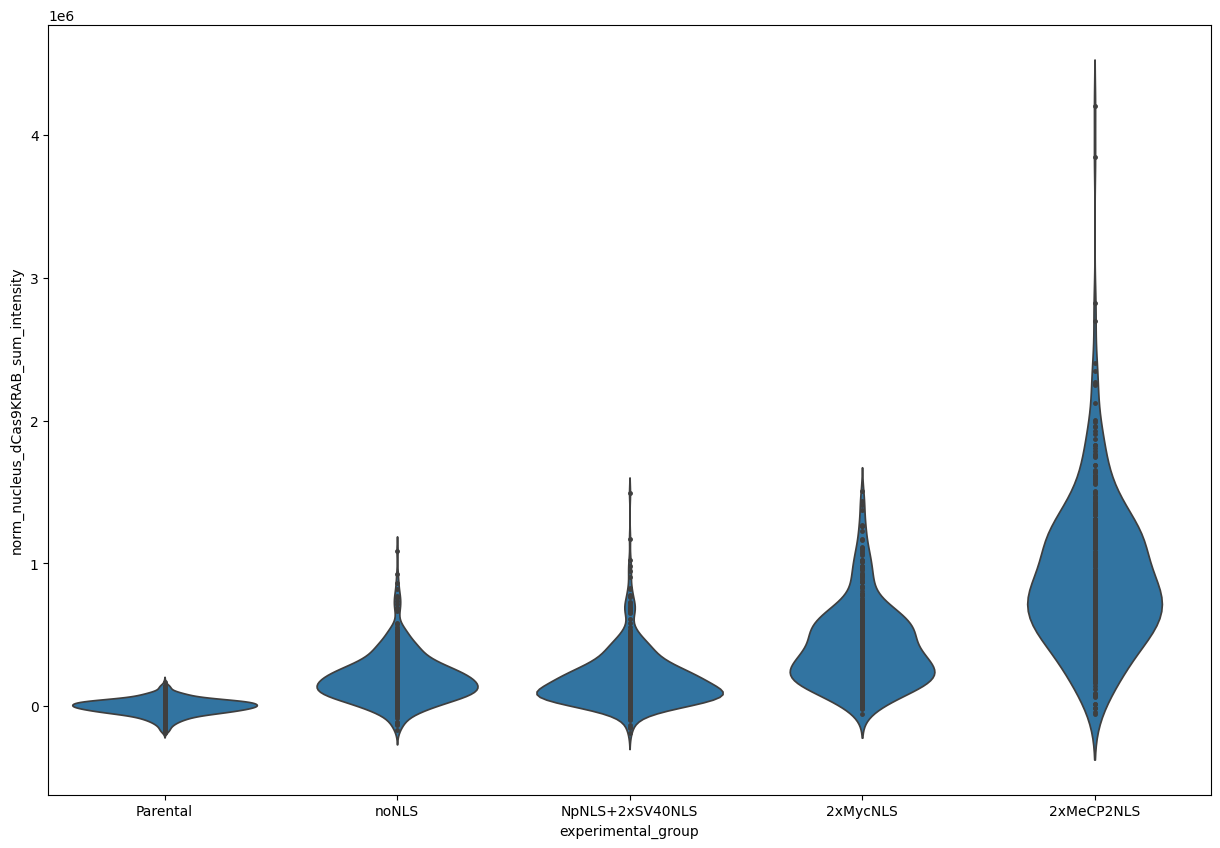

In [28]:
df["norm_nucleus_dCas9KRAB_sum_intensity"] = df["nucleus_dCas9KRAB_sum_intensity"] - parental_nuc_dCas9KRAB_mean*df["nucleus_area"]

sns.violinplot(data=df, x="experimental_group", y="norm_nucleus_dCas9KRAB_sum_intensity", order=["Parental", "noNLS", "NpNLS+2xSV40NLS", "2xMycNLS", "2xMeCP2NLS"], inner="point", density_norm="count")

<Axes: xlabel='experimental_group', ylabel='norm_cytoplasm_dCas9KRAB_mean_intensity'>

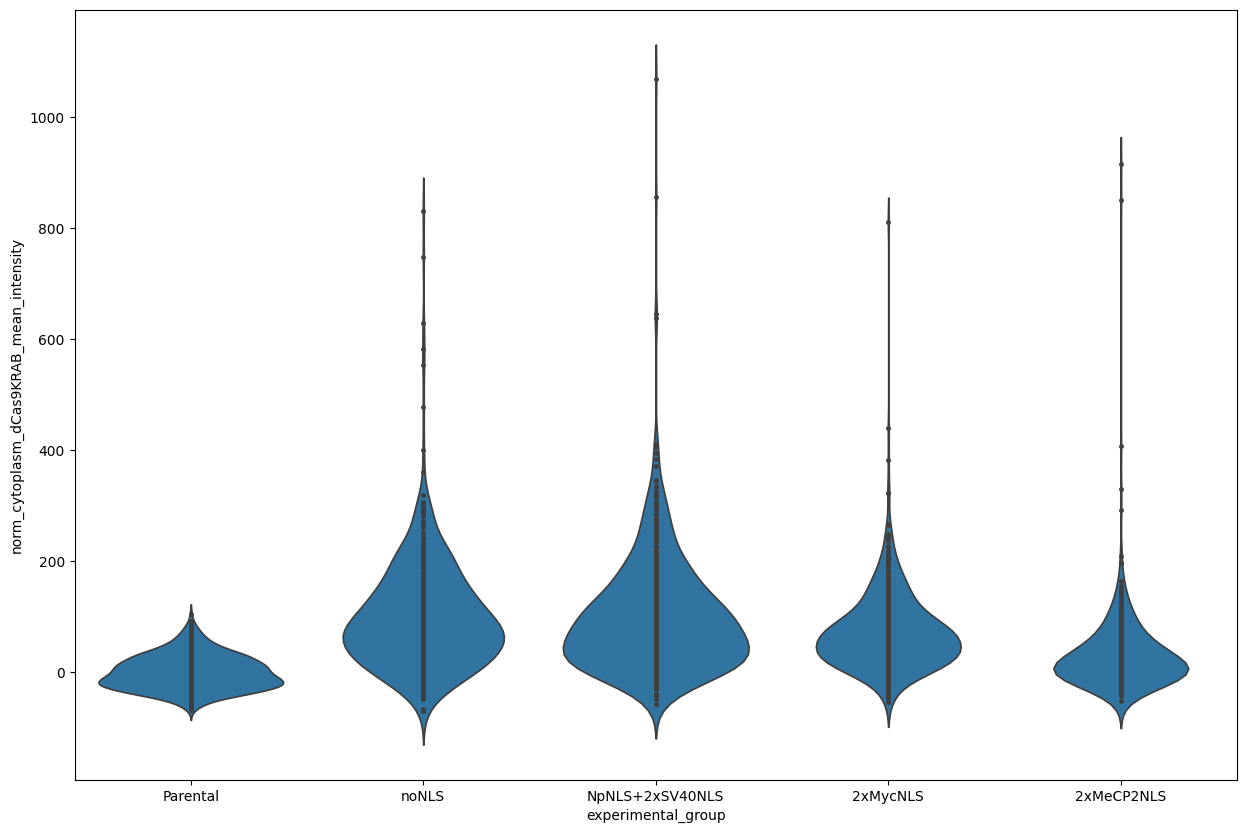

In [14]:
df["norm_cytoplasm_dCas9KRAB_mean_intensity"] = df["cytoplasm_dCas9KRAB_mean_intensity"] - parental["cytoplasm_dCas9KRAB_mean_intensity"].mean()

sns.violinplot(data=df, x="experimental_group", y="norm_cytoplasm_dCas9KRAB_mean_intensity", order=["Parental", "noNLS", "NpNLS+2xSV40NLS", "2xMycNLS", "2xMeCP2NLS"], inner="point", density_norm="count")

<Axes: xlabel='experimental_group', ylabel='norm_cytoplasm_dCas9KRAB_sum_intensity'>

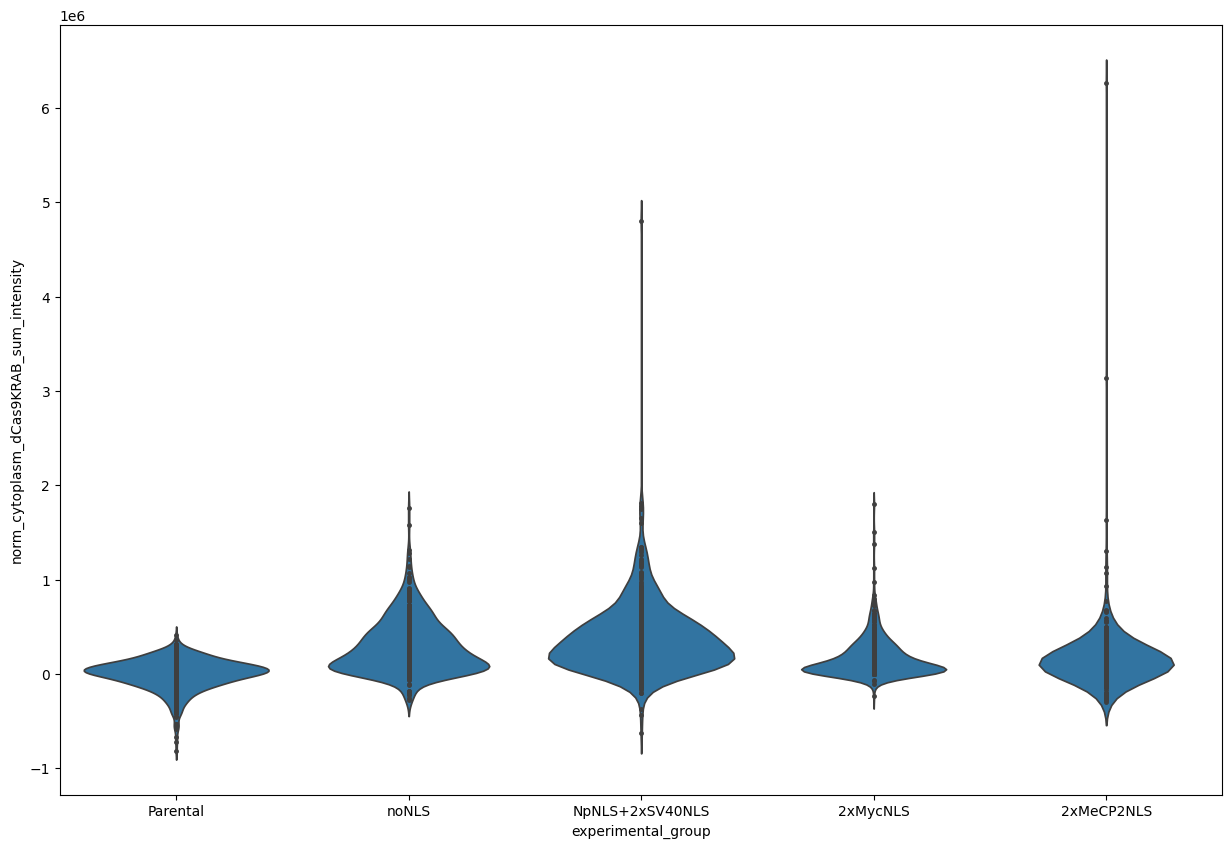

In [22]:
df["norm_cytoplasm_dCas9KRAB_sum_intensity"] = df["cytoplasm_dCas9KRAB_sum_intensity"] - ((parental["cytoplasm_dCas9KRAB_sum_intensity"].sum()/(parental["cell_area"].sum() - parental["nucleus_area"].sum()))*(df["cell_area"]-df["nucleus_area"]))

sns.violinplot(data=df, x="experimental_group", y="norm_cytoplasm_dCas9KRAB_sum_intensity", order=["Parental", "noNLS", "NpNLS+2xSV40NLS", "2xMycNLS", "2xMeCP2NLS"], inner="point", density_norm="count")

<Axes: xlabel='experimental_group', ylabel='norm_dCas9KRAB_mean_nuc_to_cyto_ratio'>

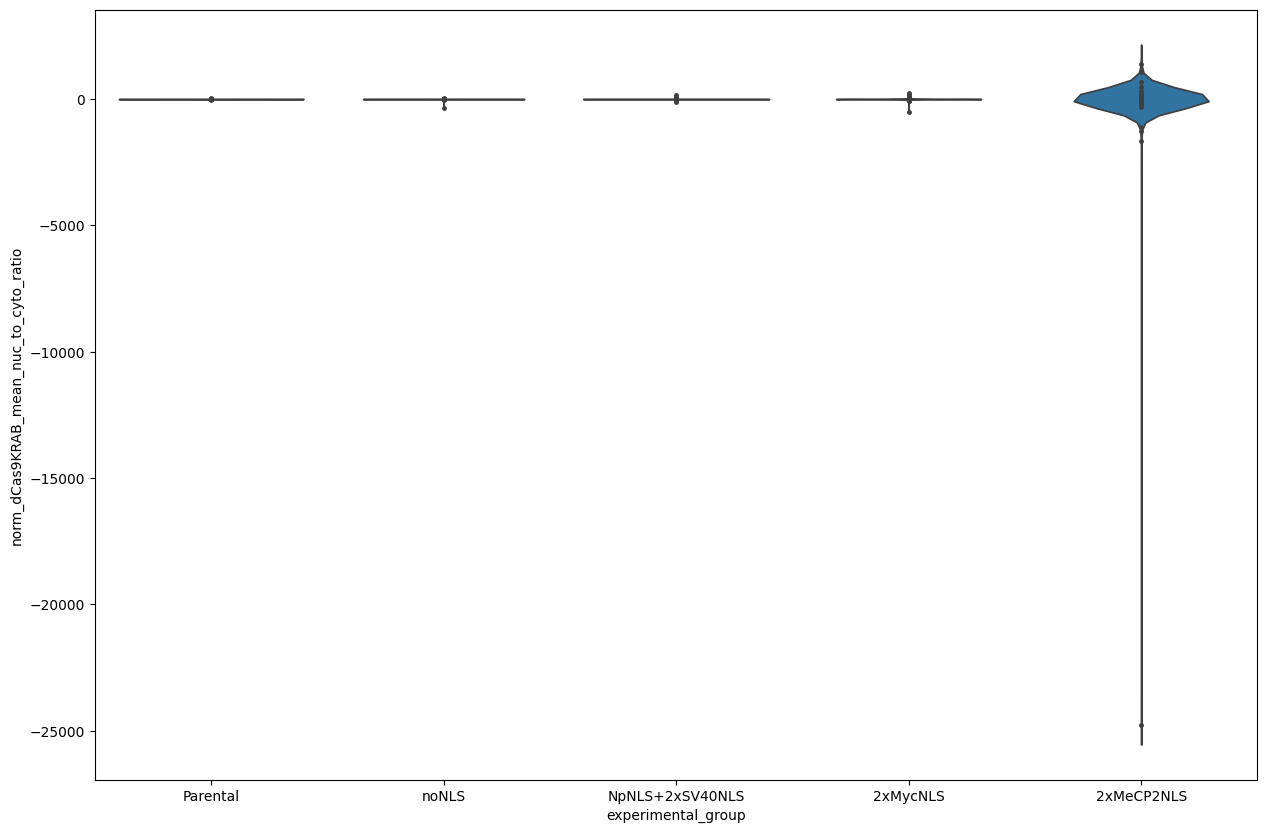

In [18]:
df["norm_dCas9KRAB_mean_nuc_to_cyto_ratio"] = df["norm_nucleus_dCas9KRAB_mean_intensity"]/df["norm_cytoplasm_dCas9KRAB_mean_intensity"]

sns.violinplot(data=df, x="experimental_group", y="norm_dCas9KRAB_mean_nuc_to_cyto_ratio", order=["Parental", "noNLS", "NpNLS+2xSV40NLS", "2xMycNLS", "2xMeCP2NLS"], inner="point", density_norm="count")